# Práctica de análisis de datos - nivel básico

In [ ]:
import pandas as pd
#librería para visualización de datos
import matplotlib.pyplot as plt
#librería para escalamiento y normalización de datos
from sklearn import preprocessing

datos=pd.read_csv('./datasets/datos_personas.csv')
datos

,ingreso,carros
0,22273.577534,3
1,8961.047249,1
2,7437.977263,2
3,12064.915290,2
4,9296.396167,1
...,...,...
995,9998.522402,0
996,6867.097603,2
997,9757.539280,1
998,11044.031510,1


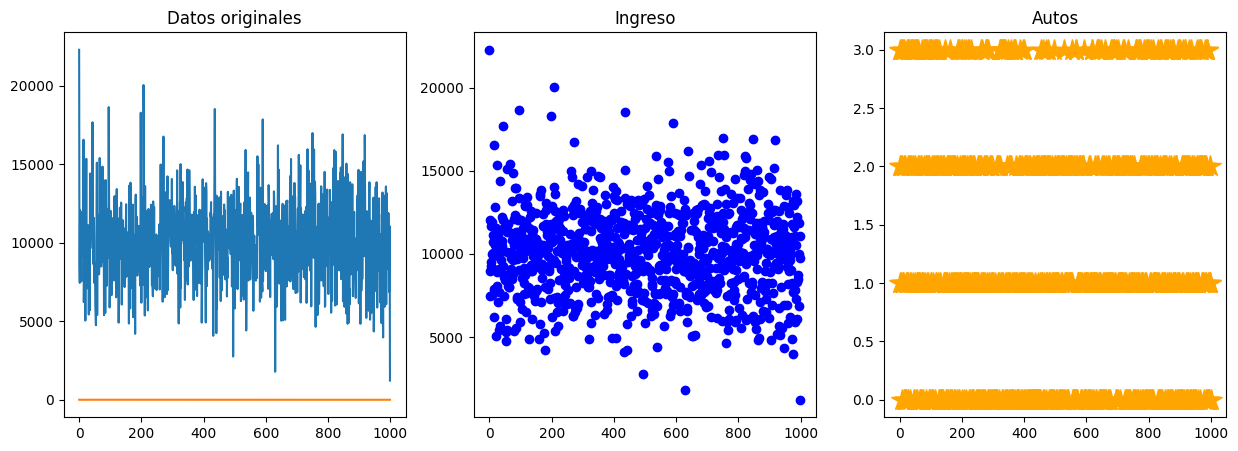

In [3]:
fig=plt.figure(figsize=(15,5))
ax1=fig.add_subplot(1,3,1)
ax2=fig.add_subplot(1,3,2)
ax3=fig.add_subplot(1,3,3)
ax1.set_title('Datos originales')
ax1.plot(datos)
ax2.set_title('Ingreso')
ax2.plot(datos['ingreso'], linewidth=0, marker='o', color='blue', markersize=6)
ax3.set_title('Autos')
ax3.plot(datos['carros'], linewidth=0, marker='*', color='orange', markersize=16)
plt.show()


# Distribución de los datos originales

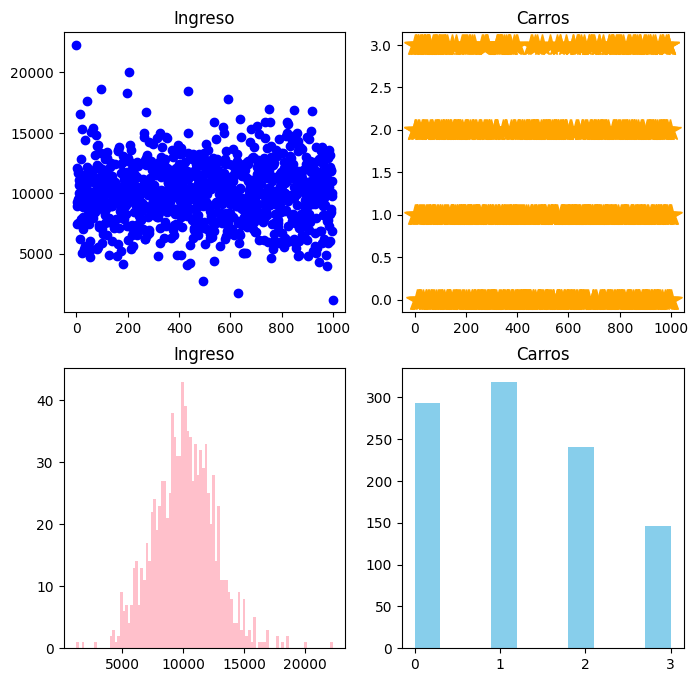

In [4]:
fig=plt.figure(figsize=(8,8))
ax1=fig.add_subplot(2,2,1)
ax2=fig.add_subplot(2,2,2)
ax3=fig.add_subplot(2,2,3)
ax4=fig.add_subplot(2,2,4)
ax1.set_title('Ingreso')
ax1.plot(datos['ingreso'], linewidth=0, marker='o', color='blue', markersize=6)
ax2.set_title('Carros')
ax2.plot(datos['carros'], linewidth=0, marker='*', color='orange', markersize=16)
ax3.set_title('Ingreso')
ax3.hist(datos['ingreso'], bins=100, color='pink')
ax4.set_title('Carros')
ax4.hist(datos['carros'], color="skyblue")
plt.show()


# Escala en función del mínimo y máximo

In [ ]:
datos_2=datos.copy()
#escalamiento de datos con MinMaxScaler
datos_min_max=preprocessing.MinMaxScaler().fit_transform(datos_2)
#convertimos el resultado a un dataframe
datos_min_max


array([[1.        , 1.        ],
       [0.36761553, 0.33333333],
       [0.29526521, 0.66666667],
       ...,
       [0.40545125, 0.33333333],
       [0.46656343, 0.33333333],
       [0.        , 0.        ]], shape=(1000, 2))

# Normaliza en función de la Norma del Vector

In [7]:
# Normalizar implica usar la norma de un vector para escalarlo, es decir, dividir cada componente del vector por su norma. 
# La norma más comúnmente utilizada es la norma L2, que se calcula como la raíz cuadrada de la suma de los cuadrados de las componentes del vector. 
# Al normalizar un vector, se obtiene un nuevo vector que tiene una longitud de 1 y apunta en la misma dirección que el vector original.
# Esto es útil en muchos algoritmos de aprendizaje automático, ya que puede ayudar a mejorar la convergencia y el rendimiento del modelo.
# Concepto de la normal en álgebra lineal
datos_normalizados=preprocessing.Normalizer().transform(datos_2.T)
datos_normalizados=datos_normalizados.T
#normaizado = X / raiz_cuadrada(X1^2 + X2^2 + ... + Xn^2)
datos_normalizados


array([[0.06777903, 0.05886881],
       [0.02726868, 0.01962294],
       [0.02263394, 0.03924588],
       ...,
       [0.02969242, 0.01962294],
       [0.03360725, 0.01962294],
       [0.00371935, 0.        ]], shape=(1000, 2))

# Estandariza (desv_std=1, media=0)

In [8]:
datos_standarizados_scaler=preprocessing.StandardScaler().fit_transform(datos_2)
#estandarizado= (X-media)/desviación estándar

datos_robust_scaler=preprocessing.RobustScaler().fit_transform(datos_2)
#robust scaler= (X-rango intercuartílico)/ desviación estándar

datos_standarizados_scaler, datos_robust_scaler

(array([[ 4.81555174,  1.70892042],
        [-0.4413019 , -0.23193185],
        [-1.04273197,  0.73849429],
        ...,
        [-0.12678303, -0.23193185],
        [ 0.38122719, -0.23193185],
        [-3.49719763, -1.20235798]], shape=(1000, 2)),
 array([[ 3.70548334,  1.        ],
        [-0.3376601 ,  0.        ],
        [-0.80023109,  0.5       ],
        ...,
        [-0.09575781,  0.        ],
        [ 0.29496225,  0.        ],
        [-2.68800607, -0.5       ]], shape=(1000, 2)))

# Columna 'ingreso': Comparación de métodos

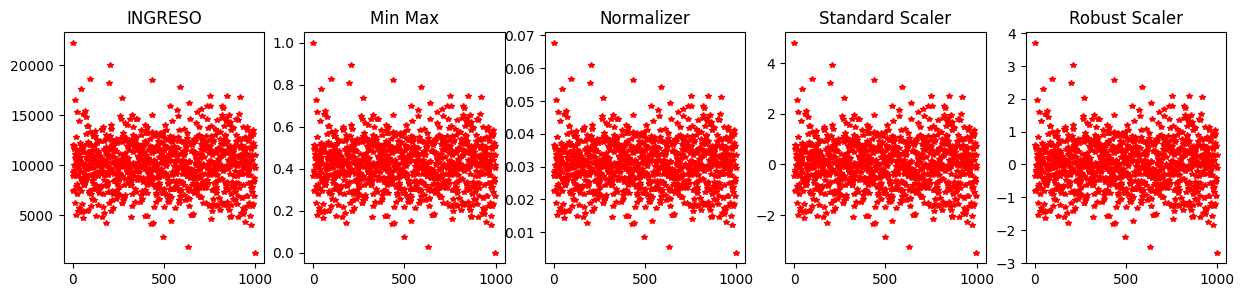

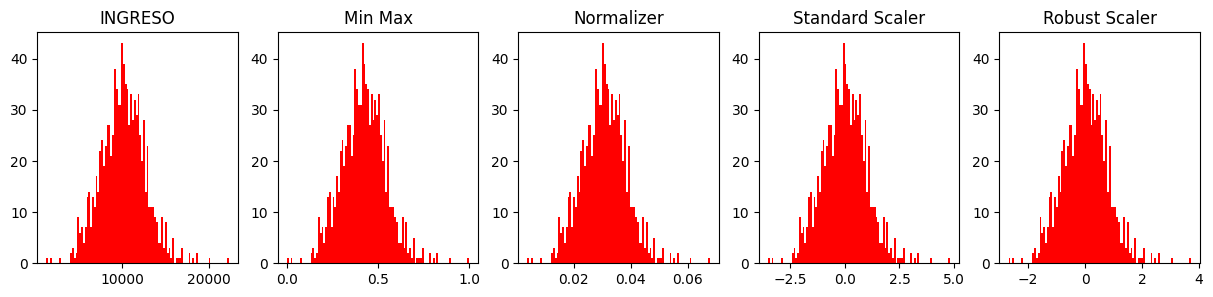

In [9]:
# convierte vectores de numpy a DataFrames para graficarlos
datos_min_max = pd.DataFrame(datos_min_max, columns=["ingreso", "carros"])
datos_normalizados = pd.DataFrame(datos_normalizados, columns=["ingreso", "carros"])
datos_standarizados_scaler = pd.DataFrame(datos_standarizados_scaler, columns=["ingreso", "carros"])
datos_robust_scaler = pd.DataFrame(datos_robust_scaler, columns=["ingreso", "carros"])

# crea una figura con 5 subfiguras para comparar los métodos
fig = plt.figure(figsize=(15, 3))
ax1 = fig.add_subplot(1, 5, 1)
ax2 = fig.add_subplot(1, 5, 2)
ax3 = fig.add_subplot(1, 5, 3)
ax4 = fig.add_subplot(1, 5, 4)
ax5 = fig.add_subplot(1, 5, 5)

# crea y personaliza series de datos
ax1.set_title("INGRESO")
ax1.plot(datos["ingreso"], linewidth=0, marker="*", color="red", markersize=4)

ax2.set_title("Min Max")
ax2.plot(datos_min_max["ingreso"], linewidth=0, marker="*", color="red", markersize=4)

ax3.set_title("Normalizer")
ax3.plot(datos_normalizados["ingreso"], linewidth=0, marker="*", color="red", markersize=4)
#ax3.set_ylim(0, 1)

ax4.set_title("Standard Scaler")
ax4.plot(datos_standarizados_scaler["ingreso"], linewidth=0, marker="*", color="red", markersize=4)

ax5.set_title("Robust Scaler")
ax5.plot(datos_robust_scaler["ingreso"], linewidth=0, marker="*", color="red", markersize=4)

plt.show()

# crea una figura con 5 subfiguras para mostrar histogramas
fig = plt.figure(figsize=(15, 3))
ax1 = fig.add_subplot(1, 5, 1)
ax2 = fig.add_subplot(1, 5, 2)
ax3 = fig.add_subplot(1, 5, 3)
ax4 = fig.add_subplot(1, 5, 4)
ax5 = fig.add_subplot(1, 5, 5)

# crea y personaliza series de datos de los histogramas
ax1.set_title("INGRESO")
ax1.hist(datos["ingreso"], color="red", bins=100)

ax2.set_title("Min Max")
ax2.hist(datos_min_max["ingreso"], color="red", bins=100)

ax3.set_title("Normalizer")
ax3.hist(datos_normalizados["ingreso"], color="red", bins=100)

ax4.set_title("Standard Scaler")
ax4.hist(datos_standarizados_scaler["ingreso"], color="red", bins=100)

ax5.set_title("Robust Scaler")
ax5.hist(datos_robust_scaler["ingreso"], color="red", bins=100)

plt.show()

# Columna 'carros': Comparación de métodos

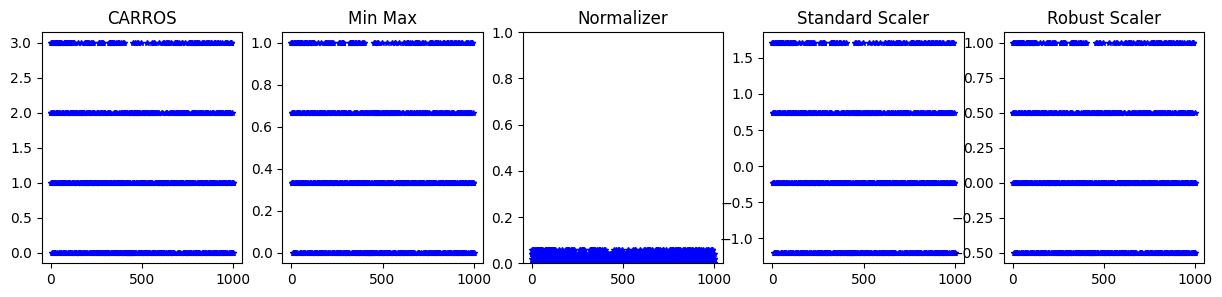

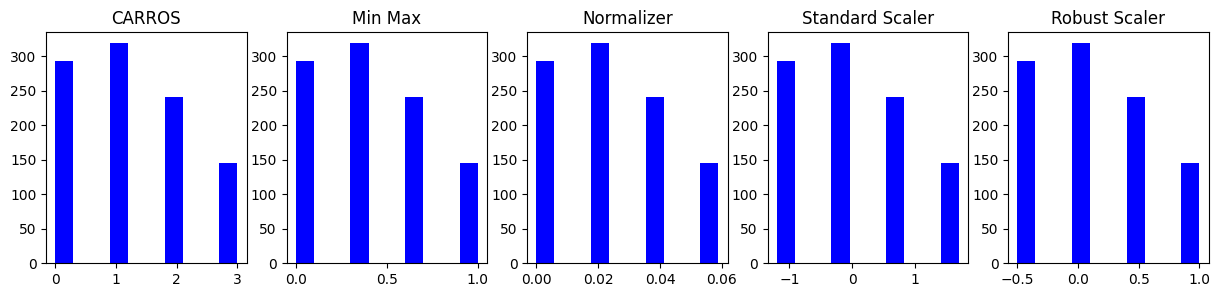

In [10]:
# crea una figura con 5 subfiguras para comparar los métodos
fig = plt.figure(figsize=(15, 3))
ax1 = fig.add_subplot(1, 5, 1)
ax2 = fig.add_subplot(1, 5, 2)
ax3 = fig.add_subplot(1, 5, 3)
ax4 = fig.add_subplot(1, 5, 4)
ax5 = fig.add_subplot(1, 5, 5)

# crea y personaliza series de datos
ax1.set_title("CARROS")
ax1.plot(datos["carros"], linewidth=0, marker="*", color="blue", markersize=4)

ax2.set_title("Min Max")
ax2.plot(datos_min_max["carros"], linewidth=0, marker="*", color="blue", markersize=4)

ax3.set_title("Normalizer")
ax3.plot(datos_normalizados["carros"], linewidth=0, marker="*", color="blue", markersize=4)
ax3.set_ylim(0, 1)

ax4.set_title("Standard Scaler")
ax4.plot(datos_standarizados_scaler["carros"], linewidth=0, marker="*", color="blue", markersize=4)

ax5.set_title("Robust Scaler")
ax5.plot(datos_robust_scaler["carros"], linewidth=0, marker="*", color="blue", markersize=4)

plt.show()

# crea una figura con 5 subfiguras para mostrar histogramas
fig = plt.figure(figsize=(15, 3))
ax1 = fig.add_subplot(1, 5, 1)
ax2 = fig.add_subplot(1, 5, 2)
ax3 = fig.add_subplot(1, 5, 3)
ax4 = fig.add_subplot(1, 5, 4)
ax5 = fig.add_subplot(1, 5, 5)

# crea y personaliza series de datos de los histogramas
ax1.set_title("CARROS")
ax1.hist(datos["carros"], color="blue")

ax2.set_title("Min Max")
ax2.hist(datos_min_max["carros"], color="blue")

ax3.set_title("Normalizer")
ax3.hist(datos_normalizados["carros"], color="blue")

ax4.set_title("Standard Scaler")
ax4.hist(datos_standarizados_scaler["carros"], color="blue")

ax5.set_title("Robust Scaler")
ax5.hist(datos_robust_scaler["carros"], color="blue")

plt.show()